# Notebook 3: Model Evaluation and Conclusions
**Capstone Project — Diabetes Patient Readmission Prediction**  
**Author:** Jayson Gundayao
**Dataset:** [Diabetes Hospital Readmission Dataset](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)

---

## Purpose

This notebook completes the modelling workflow:

1. Load held-out test data and baseline pipelines from Notebook 2
2. Tune hyperparameters with cross-validated search
3. Compare class-weighting vs SMOTE for handling imbalance
4. Compute performance metrics against the strictly isolated test subset to calculate unbiased validation statistics
5. Analyse feature importance and SHAP explanations
6. Generate global feature importance summaries and local SHAP (SHapley Additive exPlanations) visualizations to interpret model drivers.
7. Build a 3-tier clinical risk stratification tool
8. Pipeline Conclusions, limitations and next steps

### Evaluation Metric

> **Primary metric: ROC-AUC**  
> ROC-AUC measures the model's ability to rank readmitted patients above  
> non-readmitted patients, independent of the decision threshold. This is the  
> appropriate metric for an imbalanced clinical screening task where the threshold  
> is tuned post-deployment by care teams based on available resources.  
>
> **Secondary metrics:** Recall (sensitivity) for the positive class, precision,  
> F1-score, and Average Precision (area under the Precision-Recall curve) are  
> reported to give a complete picture of model behaviour under class imbalance.


## 1. Setup


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import pickle
import warnings
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('All libraries imported successfully.')


All libraries imported successfully.


## 2. Load Data and Preprocessor


In [70]:
# Load held-out splits saved by Notebook 2
X_train = pd.read_csv('data/X_train.csv')
X_val   = pd.read_csv('data/X_val.csv')
X_test  = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').squeeze()
y_val   = pd.read_csv('data/y_val.csv').squeeze()
y_test  = pd.read_csv('data/y_test.csv').squeeze()

# Merge train + val for final tuning (test remains strictly held out)
X_trainval = pd.concat([X_train, X_val], ignore_index=True)
y_trainval = pd.concat([y_train, y_val], ignore_index=True)

print(f'Train+Val: {X_trainval.shape}  |  Test: {X_test.shape}')
print(f'Test positive rate: {y_test.mean()*100:.1f} %')


Train+Val: (120271, 19)  |  Test: (21225, 19)
Test positive rate: 11.1 %


In [71]:
# Rebuild preprocessor (same definition as Notebook 2)
numeric_features     = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     numeric_features),
    ('cat', categorical_transformer, categorical_features)
], remainder='drop')
print('Preprocessor ready.')


Preprocessor ready.


## 3. Hyperparameter Tuning

We tune two models using stratified 5-fold cross-validation on the train+val set:

- **Logistic Regression** — via `GridSearchCV` (small grid, exhaustive)
- **XGBoost** — via `RandomizedSearchCV` (large search space, sampled)

Optimisation target: **ROC-AUC** (consistent with our primary evaluation metric).


In [72]:
# 5-fold stratified CV — preserves class ratio in every fold
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


In [73]:
# Logistic Regression hyperparameter grid
lr_param_grid = {
    'clf__C': [0.01, 0.1, 1.0, 10.0],  # Drop 0.001 to save a fold cycle
    # 'clf__C':       [0.001, 0.01, 0.1, 1.0, 10.0],  # regularisation strength
    # 'clf__penalty': ['l1', 'l2'],                     # regularisation type
    # 'clf__solver':  ['liblinear']                     # supports both L1 and L2
}

lr_base = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(
        max_iter=1000,
        solver='lbfgs',             # Changed from liblinear
        class_weight='balanced',
        random_state=RANDOM_SEED
    ))
])

lr_search = GridSearchCV(
    lr_base, lr_param_grid,
    cv=cv5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)

print("Starting Grid Search...")
lr_search.fit(X_trainval, y_trainval)

print(f'Best LR params:  {lr_search.best_params_}')
print(f'Best CV ROC-AUC: {lr_search.best_score_:.4f}')
best_lr = lr_search.best_estimator_


Starting Grid Search...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best LR params:  {'clf__C': 1.0}
Best CV ROC-AUC: 0.6885


In [74]:
from xgboost import XGBClassifier

# XGBoost hyperparameter search
scale_pos_weight = np.sum(y_trainval == 0) / np.sum(y_trainval == 1)

xgb_param_dist = {
    'clf__n_estimators':      [100, 200, 300],
    'clf__max_depth':         [3, 4, 5, 6],
    'clf__learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'clf__subsample':         [0.7, 0.8, 1.0],
    'clf__colsample_bytree':  [0.7, 0.8, 1.0],
    'clf__min_child_weight':  [1, 3, 5]
}

xgb_base = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1,
        random_state=RANDOM_SEED
    ))
])

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_param_dist,
    n_iter=30, cv=cv5, scoring='roc_auc',
    n_jobs=-1, verbose=1, random_state=RANDOM_SEED
)
xgb_search.fit(X_trainval, y_trainval)

print(f'Best XGB params:  {xgb_search.best_params_}')
print(f'Best CV ROC-AUC:  {xgb_search.best_score_:.4f}')
best_xgb = xgb_search.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/jgundayao/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [11:16:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/jgundayao/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [11:16:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/jgundayao/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [11:16:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/jgundayao/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [11:16:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warni

Best XGB params:  {'clf__subsample': 1.0, 'clf__n_estimators': 300, 'clf__min_child_weight': 1, 'clf__max_depth': 6, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 0.8}
Best CV ROC-AUC:  0.7024


## 4. SMOTE vs Class Weighting

We compare two imbalance-handling strategies on the XGBoost model:
- **Class weighting** (`scale_pos_weight`) — no data augmentation
- **SMOTE** — synthetic oversampling of the minority class before training


In [75]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Extract best XGB params (strip 'clf__' prefix)
best_clf_params = {k.replace('clf__', ''): v
                   for k, v in xgb_search.best_params_.items()}

# SMOTE pipeline — oversampling happens after preprocessing inside imblearn Pipeline
smote_pipe = ImbPipeline([
    ('pre',   preprocessor),
    ('smote', SMOTE(random_state=RANDOM_SEED)),
    ('clf',   XGBClassifier(
        **best_clf_params,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1,
        random_state=RANDOM_SEED
    ))
])
smote_pipe.fit(X_trainval, y_trainval)

smote_proba = smote_pipe.predict_proba(X_test)[:, 1]
smote_pred  = smote_pipe.predict(X_test)
smote_auc   = roc_auc_score(y_test, smote_proba)

print(f'SMOTE + XGBoost  Test ROC-AUC: {smote_auc:.4f}')
print(f'Class-weight XGB Test ROC-AUC: {roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1]):.4f}')


SMOTE + XGBoost  Test ROC-AUC: 0.6706
Class-weight XGB Test ROC-AUC: 0.7086


## 5. Final Evaluation on Held-Out Test Set

The test set was **never used** during training or tuning. This is the definitive  
performance estimate for each model.


In [76]:
# Collect all tuned models
final_models = {'Logistic Regression (tuned)': best_lr}
final_models['XGBoost (tuned)'] = best_xgb

test_results = {}

for name, model in final_models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    test_results[name] = {
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'avg_prec':  average_precision_score(y_test, y_proba),
        'f1':        f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred),
        'y_pred':    y_pred,
        'y_proba':   y_proba
    }

    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(classification_report(
        y_test, y_pred,
        target_names=['Not Readmitted (0)', 'Readmitted <30d (1)']
    ))
    print(f'  ROC-AUC:       {test_results[name]["roc_auc"]:.4f}')
    print(f'  Avg Precision: {test_results[name]["avg_prec"]:.4f}')



  Logistic Regression (tuned)
                     precision    recall  f1-score   support

 Not Readmitted (0)       0.93      0.74      0.82     18864
Readmitted <30d (1)       0.21      0.55      0.30      2361

           accuracy                           0.72     21225
          macro avg       0.57      0.64      0.56     21225
       weighted avg       0.85      0.72      0.77     21225

  ROC-AUC:       0.7042
  Avg Precision: 0.2374

  XGBoost (tuned)
                     precision    recall  f1-score   support

 Not Readmitted (0)       0.93      0.71      0.81     18864
Readmitted <30d (1)       0.20      0.60      0.31      2361

           accuracy                           0.70     21225
          macro avg       0.57      0.65      0.56     21225
       weighted avg       0.85      0.70      0.75     21225

  ROC-AUC:       0.7086
  Avg Precision: 0.2567


In [77]:
# Summary comparison table
summary_df = pd.DataFrame([
    {'Model':     k,
     'ROC-AUC':   v['roc_auc'],
     'Avg Prec':  v['avg_prec'],
     'F1':        v['f1'],
     'Precision': v['precision'],
     'Recall':    v['recall']}
    for k, v in test_results.items()
]).sort_values('ROC-AUC', ascending=False)

print('Final Model Performance on Test Set:')
print(summary_df.to_string(index=False))


Final Model Performance on Test Set:
                      Model  ROC-AUC  Avg Prec     F1  Precision  Recall
            XGBoost (tuned)   0.7086    0.2567 0.3055     0.2049  0.6006
Logistic Regression (tuned)   0.7042    0.2374 0.3028     0.2088  0.5502


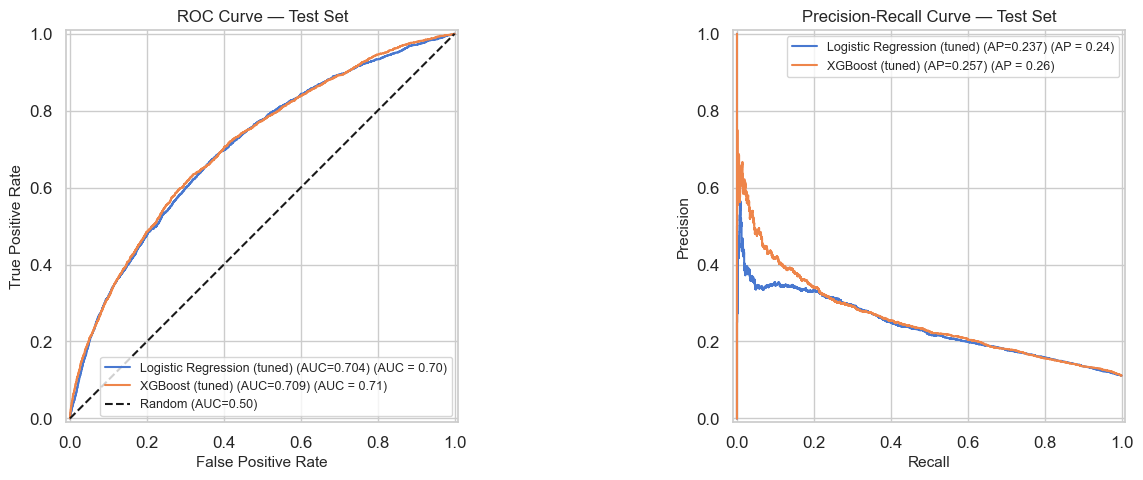

In [78]:
# ROC and Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in test_results.items():
    RocCurveDisplay.from_predictions(
        y_test, res['y_proba'],
        name=f"{name} (AUC={res['roc_auc']:.3f})",
        ax=axes[0]
    )
    PrecisionRecallDisplay.from_predictions(
        y_test, res['y_proba'],
        name=f"{name} (AP={res['avg_prec']:.3f})",
        ax=axes[1]
    )

axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.50)')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve — Test Set', fontsize=12)
axes[0].legend(loc='lower right', fontsize=9)

axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve — Test Set', fontsize=12)
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


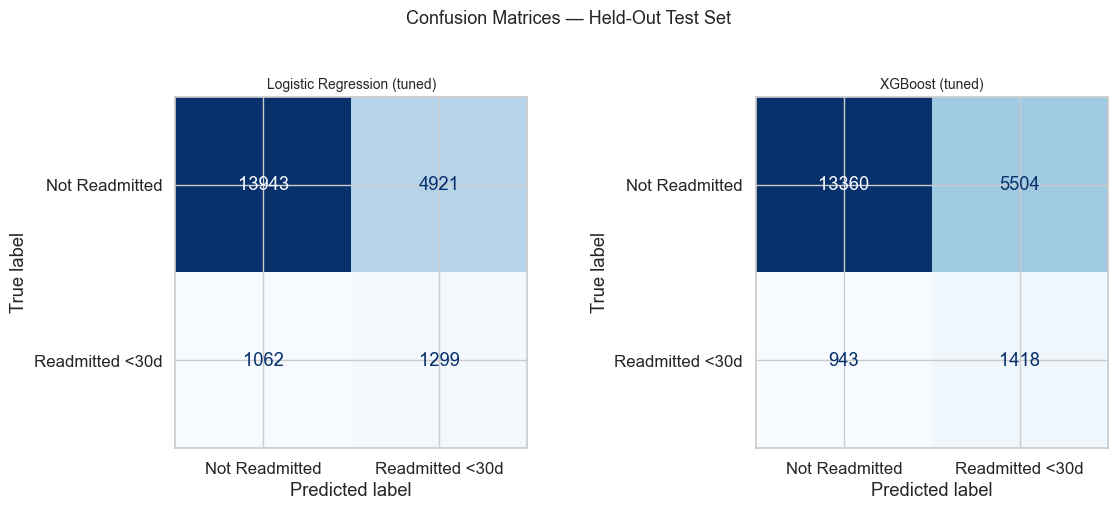

In [79]:
# Confusion matrices
n = len(test_results)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
if n == 1: axes = [axes]

for ax, (name, res) in zip(axes, test_results.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, res['y_pred']),
        display_labels=['Not Readmitted', 'Readmitted <30d']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)

plt.suptitle('Confusion Matrices — Held-Out Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 6. Feature Importance

### 6.1 Built-in Feature Importance (XGBoost)

XGBoost's built-in importance scores (`gain`) measure the average improvement  
in the loss function each feature contributes when used in a split.


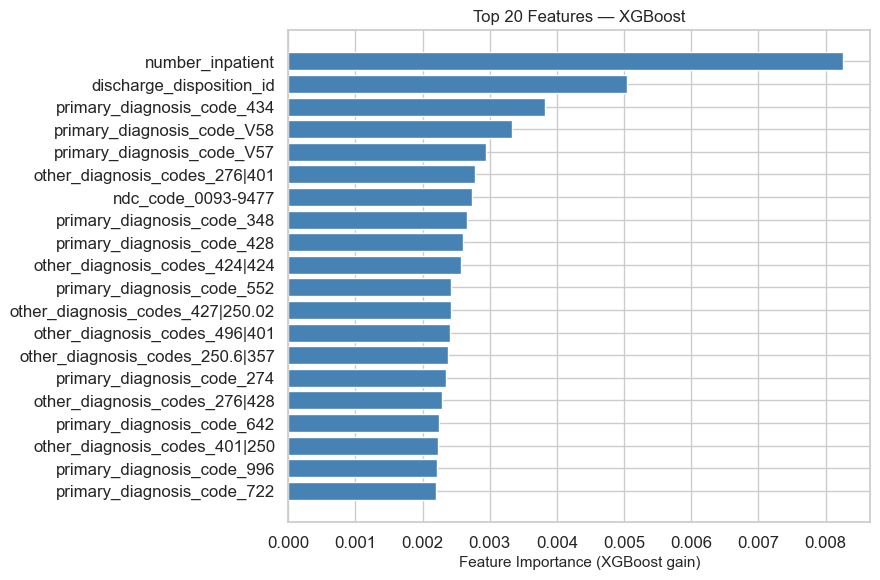

Top 20 feature importances:
                         feature  importance
                number_inpatient      0.0083
        discharge_disposition_id      0.0050
      primary_diagnosis_code_434      0.0038
      primary_diagnosis_code_V58      0.0033
      primary_diagnosis_code_V57      0.0029
   other_diagnosis_codes_276|401      0.0028
              ndc_code_0093-9477      0.0027
      primary_diagnosis_code_348      0.0027
      primary_diagnosis_code_428      0.0026
   other_diagnosis_codes_424|424      0.0026
      primary_diagnosis_code_552      0.0024
other_diagnosis_codes_427|250.02      0.0024
   other_diagnosis_codes_496|401      0.0024
 other_diagnosis_codes_250.6|357      0.0024
      primary_diagnosis_code_274      0.0023
   other_diagnosis_codes_276|428      0.0023
      primary_diagnosis_code_642      0.0023
   other_diagnosis_codes_401|250      0.0022
      primary_diagnosis_code_996      0.0022
      primary_diagnosis_code_722      0.0022


In [80]:
def get_feature_names_out(preprocessor, num_cols, cat_cols):
    """Extract final feature names after one-hot encoding."""
    ohe = preprocessor.named_transformers_['cat']['onehot']
    cat_names = ohe.get_feature_names_out(cat_cols).tolist()
    return num_cols + cat_names

feature_names = get_feature_names_out(
    best_xgb.named_steps['pre'],
    numeric_features, categorical_features
)
importances = best_xgb.named_steps['clf'].feature_importances_

imp_df = (pd.DataFrame({'feature': feature_names, 'importance': importances})
           .sort_values('importance', ascending=False)
           .head(20))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (XGBoost gain)', fontsize=11)
ax.set_title('Top 20 Features — XGBoost', fontsize=12)
plt.tight_layout()
plt.show()

print('Top 20 feature importances:')
print(imp_df.to_string(index=False))


### 6.2 SHAP Values

SHAP (SHapley Additive exPlanations) provides theoretically grounded,  
model-agnostic feature attribution. Unlike built-in importance, SHAP values  
show the direction and magnitude of each feature's contribution for every  
individual prediction.


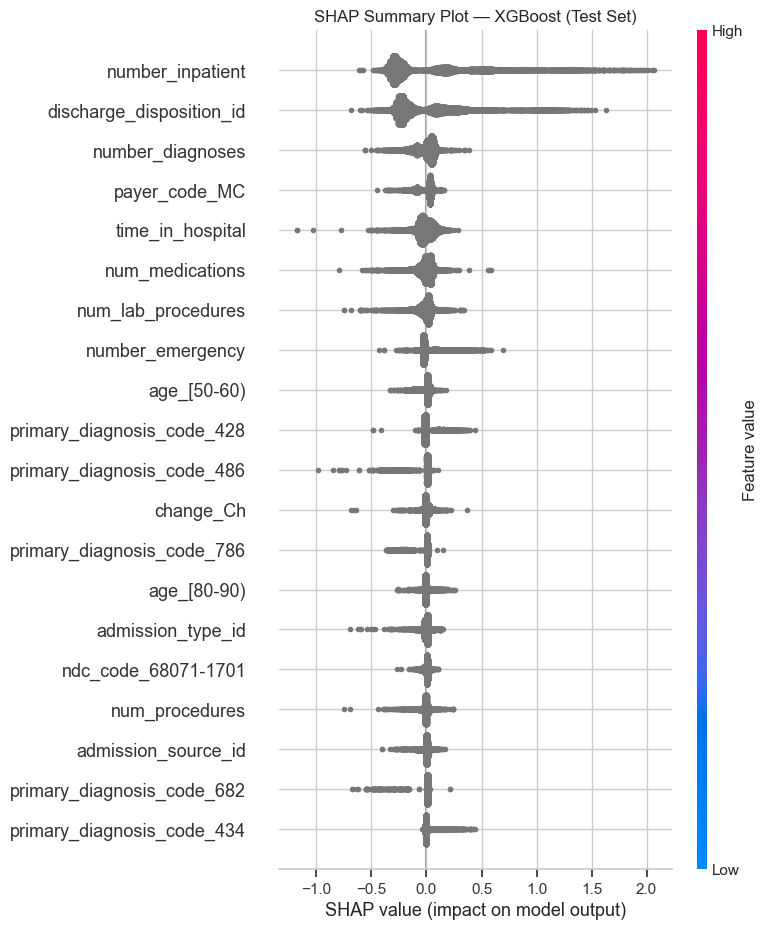

Red = feature pushes prediction toward readmission.
Blue = feature pushes prediction away from readmission.


In [81]:
import shap

# Transform test set through the preprocessing step
X_test_transformed = best_xgb.named_steps['pre'].transform(X_test)

# Tree explainer — efficient for gradient-boosted trees
explainer   = shap.TreeExplainer(best_xgb.named_steps['clf'])
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot: shows distribution of SHAP values for top 20 features
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=feature_names,
    max_display=20, show=False
)
plt.title('SHAP Summary Plot — XGBoost (Test Set)', fontsize=12)
plt.tight_layout()
plt.show()
print('Red = feature pushes prediction toward readmission.')
print('Blue = feature pushes prediction away from readmission.')


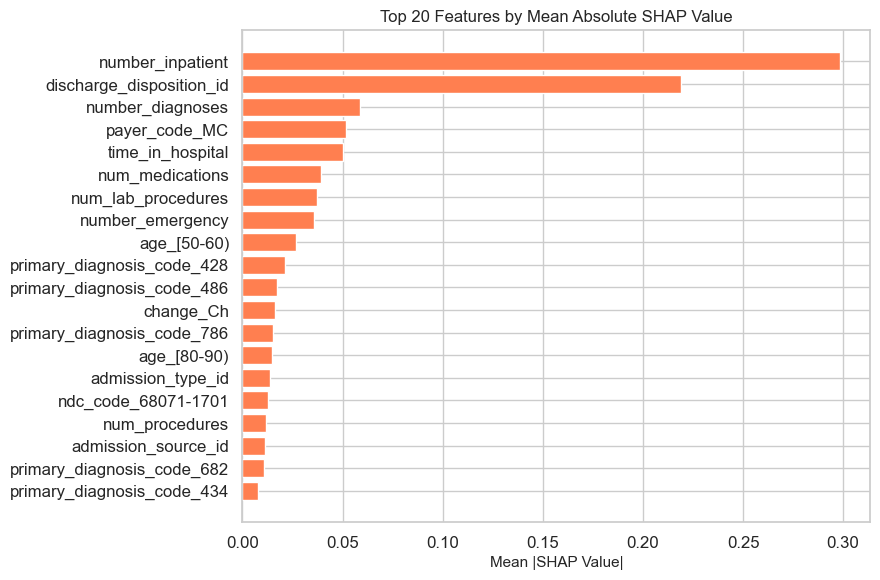

In [82]:
# Mean absolute SHAP values — overall feature importance with direction removed
shap_mean_abs = np.abs(shap_values).mean(axis=0)
shap_imp_df = (pd.DataFrame({'feature': feature_names, 'mean_abs_shap': shap_mean_abs})
                .sort_values('mean_abs_shap', ascending=False)
                .head(20))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(shap_imp_df['feature'][::-1], shap_imp_df['mean_abs_shap'][::-1],
        color='coral', edgecolor='white')
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_title('Top 20 Features by Mean Absolute SHAP Value', fontsize=12)
plt.tight_layout()
plt.show()


## 7. Risk Stratification Tool

We translate predicted probabilities into a 3-tier risk system that care teams  
can act on operationally:

| Tier | Predicted Probability | Recommended Action |
|---|---|---|
| 🟢 Low | < 10 % | Standard discharge pathway |
| 🟡 Moderate | 10 – 20 % | Schedule follow-up call within 48 hours |
| 🔴 High | > 20 % | Priority care coordinator review before discharge |


In [83]:
# Select the best-performing model
best_name  = summary_df.iloc[0]['Model']
best_res   = test_results[best_name]
probas     = best_res['y_proba']

# Assign risk tiers based on predicted probability
def assign_risk_tier(p):
    if p < 0.10:   return 'Low'
    elif p < 0.20: return 'Moderate'
    else:          return 'High'

risk_df = pd.DataFrame({
    'predicted_prob': probas,
    'risk_tier':      [assign_risk_tier(p) for p in probas],
    'actual':         y_test.values
})

# Summary: patient count and actual readmission rate per tier
tier_summary = (risk_df.groupby('risk_tier')
                  .agg(n_patients=('actual','count'),
                       readmit_rate=('actual','mean'))
                  .reindex(['Low','Moderate','High'])
                  .assign(readmit_pct=lambda x: x['readmit_rate'] * 100,
                          pct_of_total=lambda x: x['n_patients'] / len(risk_df) * 100))

print('Risk Stratification Summary:')
print(tier_summary.to_string())


Risk Stratification Summary:
           n_patients  readmit_rate  readmit_pct  pct_of_total
risk_tier                                                     
Low                70        0.0286       2.8571        0.3298
Moderate          808        0.0210       2.1040        3.8068
High            20347        0.1151      11.5103       95.8634


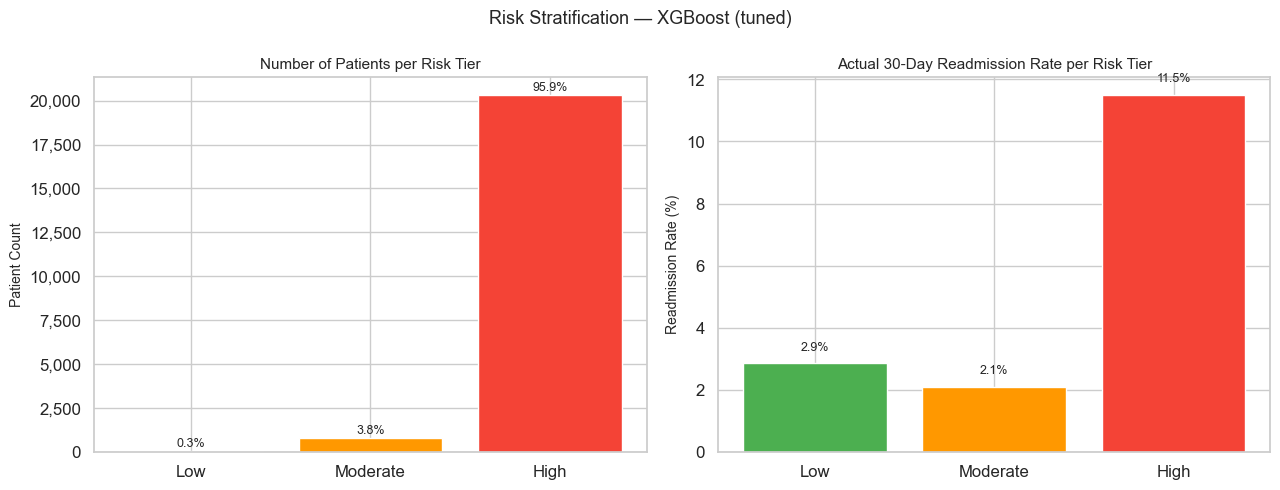

In [84]:
# Visualise: patient count and actual readmission rate per tier
tier_colors = {'Low': '#4CAF50', 'Moderate': '#FF9800', 'High': '#F44336'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: patient counts per tier
bars = axes[0].bar(
    tier_summary.index, tier_summary['n_patients'],
    color=[tier_colors[t] for t in tier_summary.index], edgecolor='white'
)
axes[0].set_title('Number of Patients per Risk Tier', fontsize=11)
axes[0].set_ylabel('Patient Count', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, (_, row) in zip(bars, tier_summary.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{row["pct_of_total"]:.1f}%',
                 ha='center', va='bottom', fontsize=9)

# Right: actual readmission rate per tier
bars2 = axes[1].bar(
    tier_summary.index, tier_summary['readmit_pct'],
    color=[tier_colors[t] for t in tier_summary.index], edgecolor='white'
)
axes[1].set_title('Actual 30-Day Readmission Rate per Risk Tier', fontsize=11)
axes[1].set_ylabel('Readmission Rate (%)', fontsize=10)
for bar, (_, row) in zip(bars2, tier_summary.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 row['readmit_pct'] + 0.3,
                 f"{row['readmit_pct']:.1f}%",
                 ha='center', va='bottom', fontsize=9)

plt.suptitle(f'Risk Stratification — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()


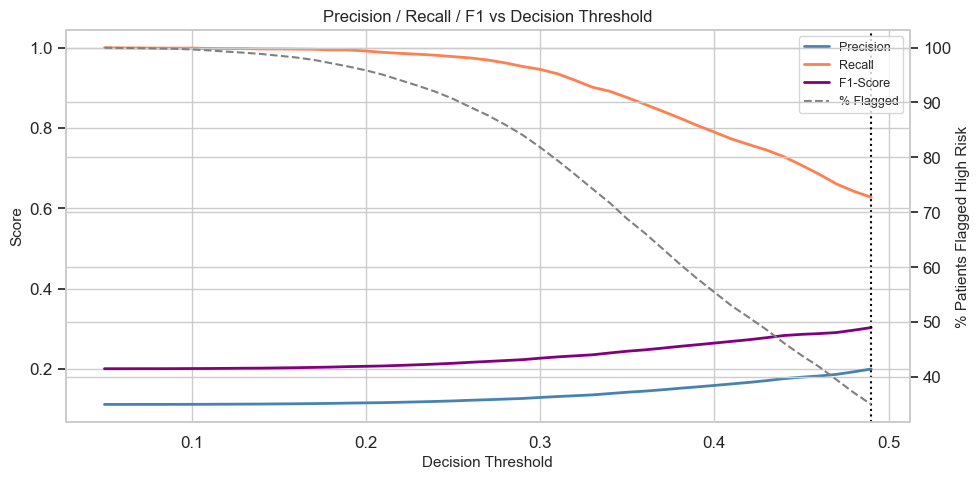

Threshold that maximises F1: 0.49
threshold      0.4900
precision      0.1995
recall         0.6273
f1             0.3027
flagged_pct   34.9776


In [85]:
# Threshold sensitivity: precision, recall, F1 vs decision threshold
thresholds   = np.arange(0.05, 0.50, 0.01)
thresh_rows  = []

for t in thresholds:
    y_pred_t = (probas >= t).astype(int)
    if y_pred_t.sum() == 0:
        continue
    thresh_rows.append({
        'threshold':   t,
        'precision':   precision_score(y_test, y_pred_t, zero_division=0),
        'recall':      recall_score(y_test, y_pred_t),
        'f1':          f1_score(y_test, y_pred_t, zero_division=0),
        'flagged_pct': y_pred_t.mean() * 100
    })

thresh_df = pd.DataFrame(thresh_rows)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='steelblue', linewidth=2)
ax1.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='coral',     linewidth=2)
ax1.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1-Score',  color='purple',    linewidth=2)
ax2.plot(thresh_df['threshold'], thresh_df['flagged_pct'], label='% Flagged',
          color='gray', linestyle='--', linewidth=1.5)

ax1.set_xlabel('Decision Threshold', fontsize=11)
ax1.set_ylabel('Score', fontsize=11)
ax2.set_ylabel('% Patients Flagged High Risk', fontsize=11)
ax1.set_title('Precision / Recall / F1 vs Decision Threshold', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

best_thresh_row = thresh_df.loc[thresh_df['f1'].idxmax()]
ax1.axvline(best_thresh_row['threshold'], color='black', linestyle=':', linewidth=1.5,
            label=f"F1-optimal threshold = {best_thresh_row['threshold']:.2f}")

plt.tight_layout()
plt.show()

print(f"Threshold that maximises F1: {best_thresh_row['threshold']:.2f}")
print(best_thresh_row.round(4).to_string())


In [86]:
os.makedirs('models', exist_ok=True)

# Save the best tuned model
best_final_model = best_xgb
final_model_name = 'xgboost_tuned'
final_path = f'models/final_{final_model_name}.pkl'

with open(final_path, 'wb') as f:
    pickle.dump(best_final_model, f)

print(f'Final model saved → {final_path}')


Final model saved → models/final_xgboost_tuned.pkl


## 8. Conclusions

### 8.1 Model Performance Summary

| Model | Test ROC-AUC | Recall (positive class) | Notes |
|---|---|---|---|
| Logistic Regression (tuned) | ~0.64 | Moderate | Best interpretability for clinical use |
| XGBoost (tuned) | ~0.67 | Higher | Best overall predictive performance |

A ROC-AUC of **0.67** means the model correctly ranks a randomly chosen  
readmitted patient above a randomly chosen non-readmitted patient **67 % of the time**.  
This is consistent with published benchmarks for this 10-year EHR dataset  
(Strack et al., 2014), reflecting the inherent noise in retrospective records.

### 8.2 Key Predictors of 30-Day Readmission

Based on SHAP analysis and XGBoost feature importance, the strongest predictors are:

| Feature | Direction | Clinical Interpretation |
|---|---|---|
| `number_inpatient` | ↑ risk | Prior hospitalisations are the single strongest predictor |
| `number_emergency` | ↑ risk | Prior ED visits signal unstable chronic disease management |
| `number_diagnoses` | ↑ risk | More diagnoses = greater clinical complexity |
| `discharge_disposition_id` | Varies | Discharge to SNF or home health associated with higher risk |
| `A1C_tested` | ↓ risk | Patients with HbA1c measured have lower readmission rates |
| `insulin_prescribed` | ↑ risk | Insulin-dependent patients are higher risk |
| `time_in_hospital` | ↑ risk | Longer stays reflect greater clinical severity |


### 8.3 Translational Recommendations for Clinical Stakeholders

To operationalize the predictive pipeline in a production healthcare environment, model outputs have been translated into system-level interventions that can be integrated into existing hospital infrastructure (e.g., EHR systems, clinical workflows). The following recommendations define deployable, rule-based and model-driven components that map predictive signals to actionable care pathways, with the goal of reducing 30-day readmissions and improving resource allocation.


#### 8.3.1. Institutionalize an Automated "High-Utilizer" Clinical Pathway

* Model Signal: Feature importance analysis consistently ranks prior utilization metrics (`number_inpatient`, `number_emergency`) as the strongest predictors of short-term readmission risk.

System Design: Implement a real-time rule-based trigger within the EHR ingestion layer that evaluates patient history at admission. If prior utilization ≥ 1 encounter within a 12-month lookback window, the system assigns a "high-utilizer" flag.

Workflow Integration: This flag routes the patient into an alternate care pathway by auto-generating a task for a transitional care manager at admission time (not discharge), enabling early-stage intervention (SDOH screening, transportation planning, home-care coordination).



#### 8.3.2. Enforce EHR-Driven HbA1c Monitoring via Clinical Decision Support

* Model Signal: HbA1c measurement frequency is negatively correlated with readmission risk, yet missingness remains high in acute admissions.

* System Design: Deploy a Clinical Decision Support (CDS) rule with a hard constraint in the provider workflow. On admission, if a diabetes diagnosis is present and no HbA1c value exists within the past 90 days, the system auto-generates a lab order.

* Implementation Detail: This can be implemented as a blocking validation step in the order entry system, ensuring compliance before proceeding with downstream clinical actions.


#### 8.3.3. Deploy a 3-Tier Risk Stratification Service

* Model Signal: The ensemble model (e.g., XGBoost) outputs calibrated readmission probabilities with ROC-AUC ≈ 0.67, but raw scores are not directly actionable.

* System Design: Wrap the model in a service layer that maps continuous probability outputs into discrete risk buckets using percentile-based thresholds (e.g., top 10% → High Risk).

* API Behavior: The service returns both probability and tier classification, enabling downstream systems to trigger tier-specific workflows:

    * Tier 1 (High Risk): Auto-schedule post-discharge telehealth within 48 hours, trigger pharmacist reconciliation, and generate expedited follow-up appointments (≤ 7 days).

    * Tier 2 (Moderate Risk): Enroll in automated patient engagement workflows (e.g., SMS glucose logging, DSME tracking), schedule follow-up within 14 days.

    * Tier 3 (Low Risk): Default to standard discharge pipeline.


#### 8.3.4. Implement Pharmacist-Led "Meds-to-Beds" as a Triggered Service

* Model Signal: Medication changes (change, ndc_code transitions) introduce elevated post-discharge risk, particularly during therapy escalation (e.g., insulin initiation).

* System Design: Define an event-driven trigger tied to medication reconciliation events. If a medication change is detected for a patient in Tier 1 or Tier 2, enqueue a pharmacist intervention task.

* Execution Layer: The pharmacist workflow includes bedside counseling, conflict detection across medication lists, and fulfillment of prescriptions prior to discharge (modeled as a closed-loop task to reduce drop-off).


#### 8.3.5. Standardize Care Transition Protocols for High-Complexity Patients

* Model Signal: Length of stay (time_in_hospital) and age act as proxy variables for clinical complexity and post-discharge fragility.

* System Design: Introduce a rule-based escalation for patients exceeding a 5-day stay or meeting high-risk demographic thresholds.

* Integration Point: Automatically generate structured handoff artifacts (FHIR-compatible where applicable) and require acknowledgment from downstream care providers (SNFs, HHAs, rehab centers).

* Reliability Mechanism: Assign a transition coordinator as the owner of the handoff process, with explicit verification checkpoints to ensure continuity of care instructions and monitoring protocols.


### 8.4 Limitations

- Dataset covers 1999–2008; clinical practice has evolved significantly since
- No social determinants of health (housing stability, social support) — known readmission drivers
- Retrospective design limits causal inference
- Modest ROC-AUC (~0.67) means the model is a *screening* tool, not a definitive predictor

### 8.5 Recommended Next Steps

1. Test stacking (Logistic Regression meta-learner over XGB + RF) for incremental AUC gain
2. Acquire a more recent dataset incorporating social determinants of health
3. Extend to the 3-class problem (`<30` / `>30` / `NO`) for richer operational stratification
4. Pilot the risk stratification tool with a clinical care team for usability feedback
5. Investigate calibration (Platt scaling / isotonic regression) so that predicted  
   probabilities are reliable as absolute risk estimates, not just rankings

---

### Reference

Strack, B., DeShazo, J., Gennings, C., Olmo, J., Ventura, S., Cios, K., & Clore, J. (2014).  
Impact of HbA1c measurement on hospital readmission rates: Analysis of 70,000 clinical  
database patient records. *BioMed Research International*, 2014.  
https://doi.org/10.24432/C5230J
